In [1]:
import win32com.client as win32
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from economic_analysis import annual_utility_cost
from economic_analysis import total_energy

In [2]:
path = os.path.abspath("ethyl-acetate-optimization - heat integration.bkp")
aspen = win32.Dispatch("Apwn.Document")
aspen.InitFromArchive2(path)

In [3]:
aspen.Tree.FindNode(
    r"\Data\Blocks\RADFRAC1\Input\PRES1"
).Value = 1.0

aspen.Tree.FindNode(
    r"\Data\Blocks\RADFRAC1\Input\BASIS_RR"
).Value = 2.0

aspen.Engine.Run2()

In [4]:
feed_ratios = np.arange(0.5, 2.1, 0.1)

results = []

In [5]:
for ratio in feed_ratios:

    print(f"Running Feed Ratio = {ratio:.2f}")

    ethanol = 100 * ratio / (1 + ratio)

    acetic = 100 - ethanol

    aspen.Tree.FindNode(
    r"\Data\Streams\ETH-ACE\Input\FLOW\MIXED\ETHANOL"
    ).Value = ethanol

    aspen.Tree.FindNode(
    r"\Data\Streams\ETH-ACE\Input\FLOW\MIXED\ACETI-01"
    ).Value = acetic

    aspen.Engine.Run2()


    purity = aspen.Tree.FindNode(
        r"\Data\Streams\LIQ-DIST\Output\MOLEFRAC\MIXED\ETHYL-01"
    ).Value

    condenser = aspen.Tree.FindNode(
        r"\Data\Blocks\RADFRAC1\Output\COND_DUTY"
    ).Value

    reboiler = aspen.Tree.FindNode(
        r"\Data\Blocks\RADFRAC1\Output\REB_DUTY"
    ).Value

    conversion = aspen.Tree.FindNode(
        r"\Data\Streams\LIQ-DIST\Output\MOLEFLOW\MIXED\ETHYL-01"
    ).Value

    cost = annual_utility_cost(        
    condenser,
    reboiler)

    energy = total_energy(
    condenser,
    reboiler)

    results.append([
    ratio,
    conversion,
    purity,
    condenser,
    reboiler,
    energy,
    cost])

Running Feed Ratio = 0.50
Running Feed Ratio = 0.60
Running Feed Ratio = 0.70
Running Feed Ratio = 0.80
Running Feed Ratio = 0.90
Running Feed Ratio = 1.00
Running Feed Ratio = 1.10
Running Feed Ratio = 1.20
Running Feed Ratio = 1.30
Running Feed Ratio = 1.40
Running Feed Ratio = 1.50
Running Feed Ratio = 1.60
Running Feed Ratio = 1.70
Running Feed Ratio = 1.80
Running Feed Ratio = 1.90
Running Feed Ratio = 2.00


In [13]:
df = pd.DataFrame(
    results,
    columns=[
        "Feed Ratio",
        "Conversion",
        "Purity",
        "Condenser Duty",
        "Reboiler Duty",
        "Total Energy",
        "Annual Utility Cost"
    ]
)

os.makedirs("data", exist_ok=True)
df.to_csv("data/ratio_results.csv", index=False)

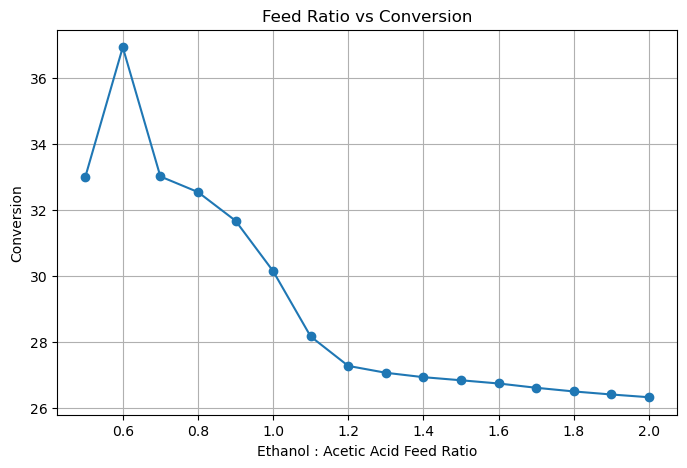

In [10]:
plt.figure(figsize=(8,5))
plt.plot(df["Feed Ratio"], df["Conversion"], marker="o")
plt.xlabel("Ethanol : Acetic Acid Feed Ratio")
plt.ylabel("Conversion")
plt.title("Feed Ratio vs Conversion")
plt.grid(True)
plt.show()

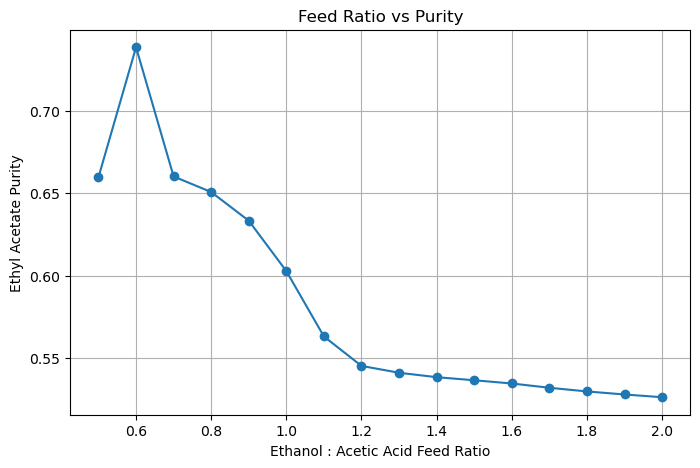

In [11]:
plt.figure(figsize=(8,5))
plt.plot(df["Feed Ratio"], df["Purity"], marker="o")
plt.xlabel("Ethanol : Acetic Acid Feed Ratio")
plt.ylabel("Ethyl Acetate Purity")
plt.title("Feed Ratio vs Purity")
plt.grid(True)
plt.show()

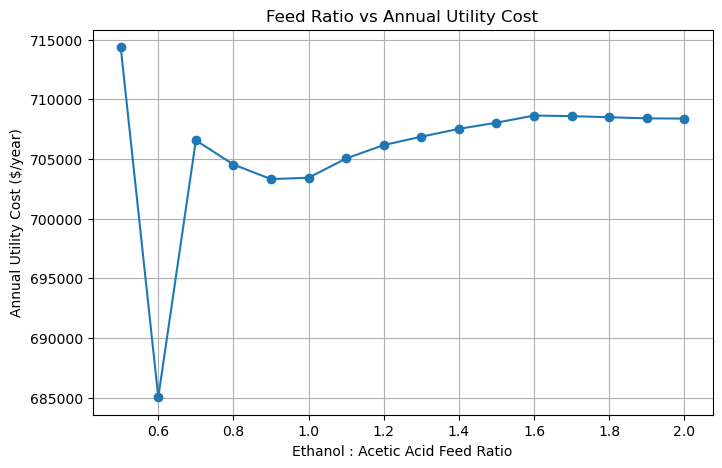

In [12]:
plt.figure(figsize=(8,5))
plt.plot(df["Feed Ratio"], df["Annual Utility Cost"], marker="o")
plt.xlabel("Ethanol : Acetic Acid Feed Ratio")
plt.ylabel("Annual Utility Cost ($/year)")
plt.title("Feed Ratio vs Annual Utility Cost")
plt.grid(True)
plt.show()

In [14]:
aspen.Close()
del aspen